## Imports & Paths

In [1]:

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

INPUT_DIR = Path(".")
OUT_DIR = INPUT_DIR / "S17_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VARIANTS = ["FULL", "CLINICAL", "BIOMARKERS"]
BASE_THRESHOLD = 0.67
THRESHOLDS = [0.50, 0.60, 0.67, 0.75, 0.80]
CLASS_ORDER = ["TRUE_SIGNAL", "SPURIOUS_IMPORTANCE", "HIDDEN_SIGNAL", "LOW_SIGNAL", "UNRESOLVED"]

CONFIG = {
    "variants": VARIANTS,
    "base_threshold": BASE_THRESHOLD,
    "thresholds": THRESHOLDS,
    "class_order": CLASS_ORDER,
    "input_file": "S15_feature_reliability_table.csv",
}

with open(OUT_DIR / "S17_config_snapshot.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

## Load input

In [2]:

feature_table = pd.read_csv(INPUT_DIR / "S15_feature_reliability_table.csv")
feature_table.head()

,variant,winner_model,feature,importance_mean_raw,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,winner_diag_signal_score,winner_diag_effect_score,winner_model_reliability_score,FRS_raw,FRS,FRS_rank,interpretability_gap,feature_class
0,BIOMARKERS,RF_SHALLOW,72_kda_pro_mmp_2,0.285683,0.285683,1.0,0.137619,0.148750,0.137619,0.148750,1.000000,1.000000,0.000000,0.0,0.607730,0.803865,0.000000,1.0,0.549557,0.774779,0.601288,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE
1,BIOMARKERS,RF_SHALLOW,hdl,0.021032,0.021032,5.0,0.474762,0.378125,0.474762,0.378125,0.073619,0.555556,0.758842,1.0,0.975067,0.765311,0.879421,1.0,0.549557,0.774779,0.572784,0.936306,2.0,-0.805802,HIDDEN_SIGNAL
2,BIOMARKERS,RF_SHALLOW,wyniki_fgf23_pg_ml,0.048952,0.048952,3.0,0.340476,0.298125,0.340476,0.298125,0.171352,0.777778,0.456592,0.0,0.959027,0.868402,0.228296,1.0,0.549557,0.774779,0.422684,0.600903,3.0,-0.056943,LOW_SIGNAL
3,BIOMARKERS,RF_SHALLOW,emmprin,0.058841,0.058841,2.0,0.245238,0.247500,0.245238,0.247500,0.205967,0.888889,0.242229,0.0,0.958375,0.923632,0.121115,1.0,0.549557,0.774779,0.416905,0.587990,4.0,0.084853,LOW_SIGNAL
4,BIOMARKERS,RF_SHALLOW,tnfalfa_pg_ml,0.029333,0.029333,4.0,0.403810,0.355000,0.403810,0.355000,0.102678,0.666667,0.599143,0.0,0.965755,0.816211,0.299571,1.0,0.549557,0.774779,0.406153,0.563966,5.0,-0.196893,LOW_SIGNAL


## Helper functions

In [3]:


def classify_feature_threshold(row, thr):
    importance = pd.to_numeric(row.get("importance_score"), errors="coerce")
    ablation = pd.to_numeric(row.get("ablation_score"), errors="coerce")
    stability = pd.to_numeric(row.get("stability_score"), errors="coerce")

    if pd.isna(importance) or pd.isna(ablation) or pd.isna(stability):
        return "UNRESOLVED"

    high_importance = importance >= thr
    high_ablation = ablation >= thr
    high_stability = stability >= thr

    if high_importance and high_ablation and high_stability:
        return "TRUE_SIGNAL"
    elif high_importance and not high_ablation:
        return "SPURIOUS_IMPORTANCE"
    elif (not high_importance) and high_ablation:
        return "HIDDEN_SIGNAL"
    else:
        return "LOW_SIGNAL"


def pairwise_class_agreement(a, b):
    valid = (~a.isna()) & (~b.isna())
    if valid.sum() == 0:
        return np.nan
    return float((a[valid] == b[valid]).mean())


def jaccard_top_features(df, score_col="FRS", top_n=10):
    rows = []
    for variant, sub in df.groupby("variant"):
        base = (
            sub[sub["threshold"] == BASE_THRESHOLD]
            .sort_values(score_col, ascending=False)
            .head(top_n)["feature"]
        )
        base_set = set(base)

        for thr, sub_thr in sub.groupby("threshold"):
            cur = sub_thr.sort_values(score_col, ascending=False).head(top_n)["feature"]
            cur_set = set(cur)
            union = base_set | cur_set
            inter = base_set & cur_set
            jacc = len(inter) / len(union) if union else np.nan

            rows.append({
                "variant": variant,
                "threshold": thr,
                "top_n": top_n,
                "jaccard_vs_base": jacc,
                "n_overlap": len(inter),
            })
    return pd.DataFrame(rows)

## Reclassify across thresholds

In [4]:

records = []

for thr in THRESHOLDS:
    tmp = feature_table.copy()
    tmp["threshold"] = thr
    tmp["feature_class_threshold"] = tmp.apply(lambda row: classify_feature_threshold(row, thr), axis=1)
    tmp["feature_class_threshold"] = pd.Categorical(
        tmp["feature_class_threshold"],
        categories=CLASS_ORDER,
        ordered=True
    )
    records.append(tmp)

threshold_long = pd.concat(records, ignore_index=True)
threshold_long.head()

,variant,winner_model,feature,importance_mean_raw,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,winner_diag_signal_score,winner_diag_effect_score,winner_model_reliability_score,FRS_raw,FRS,FRS_rank,interpretability_gap,feature_class,threshold,feature_class_threshold
0,BIOMARKERS,RF_SHALLOW,72_kda_pro_mmp_2,0.285683,0.285683,1.0,0.137619,0.148750,0.137619,0.148750,1.000000,1.000000,0.000000,0.0,0.607730,0.803865,0.000000,1.0,0.549557,0.774779,0.601288,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE,0.5,SPURIOUS_IMPORTANCE
1,BIOMARKERS,RF_SHALLOW,hdl,0.021032,0.021032,5.0,0.474762,0.378125,0.474762,0.378125,0.073619,0.555556,0.758842,1.0,0.975067,0.765311,0.879421,1.0,0.549557,0.774779,0.572784,0.936306,2.0,-0.805802,HIDDEN_SIGNAL,0.5,HIDDEN_SIGNAL
2,BIOMARKERS,RF_SHALLOW,wyniki_fgf23_pg_ml,0.048952,0.048952,3.0,0.340476,0.298125,0.340476,0.298125,0.171352,0.777778,0.456592,0.0,0.959027,0.868402,0.228296,1.0,0.549557,0.774779,0.422684,0.600903,3.0,-0.056943,LOW_SIGNAL,0.5,LOW_SIGNAL
3,BIOMARKERS,RF_SHALLOW,emmprin,0.058841,0.058841,2.0,0.245238,0.247500,0.245238,0.247500,0.205967,0.888889,0.242229,0.0,0.958375,0.923632,0.121115,1.0,0.549557,0.774779,0.416905,0.587990,4.0,0.084853,LOW_SIGNAL,0.5,LOW_SIGNAL
4,BIOMARKERS,RF_SHALLOW,tnfalfa_pg_ml,0.029333,0.029333,4.0,0.403810,0.355000,0.403810,0.355000,0.102678,0.666667,0.599143,0.0,0.965755,0.816211,0.299571,1.0,0.549557,0.774779,0.406153,0.563966,5.0,-0.196893,LOW_SIGNAL,0.5,HIDDEN_SIGNAL


## Class counts by threshold and variant

In [5]:

class_count_summary = (
    threshold_long.groupby(["variant", "threshold", "feature_class_threshold"], observed=False)
    .agg(n_features=("feature", "nunique"))
    .reset_index()
    .sort_values(["variant", "threshold", "feature_class_threshold"])
)

class_count_summary.to_csv(OUT_DIR / "S17_class_count_summary.csv", index=False)
class_count_summary.head(20)

,variant,threshold,feature_class_threshold,n_features
0,BIOMARKERS,0.50,TRUE_SIGNAL,0
1,BIOMARKERS,0.50,SPURIOUS_IMPORTANCE,1
2,BIOMARKERS,0.50,HIDDEN_SIGNAL,6
3,BIOMARKERS,0.50,LOW_SIGNAL,2
4,BIOMARKERS,0.50,UNRESOLVED,1
5,BIOMARKERS,0.60,TRUE_SIGNAL,0
6,BIOMARKERS,0.60,SPURIOUS_IMPORTANCE,1
7,BIOMARKERS,0.60,HIDDEN_SIGNAL,5
8,BIOMARKERS,0.60,LOW_SIGNAL,3
9,BIOMARKERS,0.60,UNRESOLVED,1


## Wide count table for quick inspection

In [6]:


class_count_wide = (
    class_count_summary.pivot_table(
        index=["variant", "threshold"],
        columns="feature_class_threshold",
        values="n_features",
        fill_value=0
    )
    .reset_index()
)

class_count_wide.to_csv(OUT_DIR / "S17_class_count_summary_wide.csv", index=False)
class_count_wide

/tmp/ipykernel_48586/337130275.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  class_count_summary.pivot_table(


feature_class_threshold,variant,threshold,TRUE_SIGNAL,SPURIOUS_IMPORTANCE,HIDDEN_SIGNAL,LOW_SIGNAL,UNRESOLVED
0,BIOMARKERS,0.50,0.0,1.0,6.0,2.0,1.0
1,BIOMARKERS,0.60,0.0,1.0,5.0,3.0,1.0
2,BIOMARKERS,0.67,0.0,1.0,4.0,4.0,1.0
3,BIOMARKERS,0.75,0.0,1.0,3.0,5.0,1.0
4,BIOMARKERS,0.80,0.0,1.0,2.0,6.0,1.0
5,CLINICAL,0.50,0.0,1.0,7.0,12.0,23.0
6,CLINICAL,0.60,0.0,1.0,5.0,14.0,23.0
7,CLINICAL,0.67,0.0,1.0,4.0,15.0,23.0
8,CLINICAL,0.75,0.0,1.0,2.0,17.0,23.0
9,CLINICAL,0.80,0.0,1.0,2.0,17.0,23.0


## Agreement with baseline threshold

In [7]:

agreement_rows = []

base_df = threshold_long[threshold_long["threshold"] == BASE_THRESHOLD][
    ["variant", "feature", "feature_class_threshold"]
].rename(columns={"feature_class_threshold": "base_class"})

for thr in THRESHOLDS:
    cur_df = threshold_long[threshold_long["threshold"] == thr][
        ["variant", "feature", "feature_class_threshold"]
    ].rename(columns={"feature_class_threshold": "current_class"})

    merged = base_df.merge(cur_df, on=["variant", "feature"], how="inner", validate="one_to_one")

    for variant, sub in merged.groupby("variant"):
        agreement_rows.append({
            "variant": variant,
            "threshold": thr,
            "agreement_vs_base": pairwise_class_agreement(sub["base_class"], sub["current_class"]),
            "n_features": int(sub["feature"].nunique()),
        })

agreement_summary = pd.DataFrame(agreement_rows).sort_values(["variant", "threshold"])
agreement_summary.to_csv(OUT_DIR / "S17_agreement_vs_base.csv", index=False)
agreement_summary

,variant,threshold,agreement_vs_base,n_features
0,BIOMARKERS,0.50,0.800000,10
3,BIOMARKERS,0.60,0.900000,10
6,BIOMARKERS,0.67,1.000000,10
9,BIOMARKERS,0.75,0.900000,10
12,BIOMARKERS,0.80,0.800000,10
1,CLINICAL,0.50,0.930233,43
4,CLINICAL,0.60,0.976744,43
7,CLINICAL,0.67,1.000000,43
10,CLINICAL,0.75,0.953488,43
13,CLINICAL,0.80,0.953488,43


## Top-feature stability across thresholds

In [8]:

top_feature_stability = jaccard_top_features(threshold_long, score_col="FRS", top_n=10)
top_feature_stability.to_csv(OUT_DIR / "S17_top_feature_stability.csv", index=False)
top_feature_stability

,variant,threshold,top_n,jaccard_vs_base,n_overlap
0,BIOMARKERS,0.50,10,1.0,10
1,BIOMARKERS,0.60,10,1.0,10
2,BIOMARKERS,0.67,10,1.0,10
3,BIOMARKERS,0.75,10,1.0,10
4,BIOMARKERS,0.80,10,1.0,10
5,CLINICAL,0.50,10,1.0,10
6,CLINICAL,0.60,10,1.0,10
7,CLINICAL,0.67,10,1.0,10
8,CLINICAL,0.75,10,1.0,10
9,CLINICAL,0.80,10,1.0,10


## Track whether any TRUE_SIGNAL appears under alternative thresholds

In [9]:


true_signal_summary = (
    class_count_summary[class_count_summary["feature_class_threshold"] == "TRUE_SIGNAL"]
    .rename(columns={"n_features": "n_true_signal"})
    .sort_values(["variant", "threshold"])
)

true_signal_summary.to_csv(OUT_DIR / "S17_true_signal_summary.csv", index=False)
true_signal_summary

,variant,threshold,feature_class_threshold,n_true_signal
0,BIOMARKERS,0.50,TRUE_SIGNAL,0
5,BIOMARKERS,0.60,TRUE_SIGNAL,0
10,BIOMARKERS,0.67,TRUE_SIGNAL,0
15,BIOMARKERS,0.75,TRUE_SIGNAL,0
20,BIOMARKERS,0.80,TRUE_SIGNAL,0
25,CLINICAL,0.50,TRUE_SIGNAL,0
30,CLINICAL,0.60,TRUE_SIGNAL,0
35,CLINICAL,0.67,TRUE_SIGNAL,0
40,CLINICAL,0.75,TRUE_SIGNAL,0
45,CLINICAL,0.80,TRUE_SIGNAL,0


In [10]:


publication_summary = class_count_wide.merge(
    agreement_summary,
    on=["variant", "threshold"],
    how="left"
).merge(
    top_feature_stability[["variant", "threshold", "jaccard_vs_base", "n_overlap"]],
    on=["variant", "threshold"],
    how="left"
)

publication_summary.to_csv(OUT_DIR / "S17_publication_summary.csv", index=False)
publication_summary

,variant,threshold,TRUE_SIGNAL,SPURIOUS_IMPORTANCE,HIDDEN_SIGNAL,LOW_SIGNAL,UNRESOLVED,agreement_vs_base,n_features,jaccard_vs_base,n_overlap
0,BIOMARKERS,0.50,0.0,1.0,6.0,2.0,1.0,0.800000,10,1.0,10
1,BIOMARKERS,0.60,0.0,1.0,5.0,3.0,1.0,0.900000,10,1.0,10
2,BIOMARKERS,0.67,0.0,1.0,4.0,4.0,1.0,1.000000,10,1.0,10
3,BIOMARKERS,0.75,0.0,1.0,3.0,5.0,1.0,0.900000,10,1.0,10
4,BIOMARKERS,0.80,0.0,1.0,2.0,6.0,1.0,0.800000,10,1.0,10
5,CLINICAL,0.50,0.0,1.0,7.0,12.0,23.0,0.930233,43,1.0,10
6,CLINICAL,0.60,0.0,1.0,5.0,14.0,23.0,0.976744,43,1.0,10
7,CLINICAL,0.67,0.0,1.0,4.0,15.0,23.0,1.000000,43,1.0,10
8,CLINICAL,0.75,0.0,1.0,2.0,17.0,23.0,0.953488,43,1.0,10
9,CLINICAL,0.80,0.0,1.0,2.0,17.0,23.0,0.953488,43,1.0,10


## Plot 1: class counts across thresholds

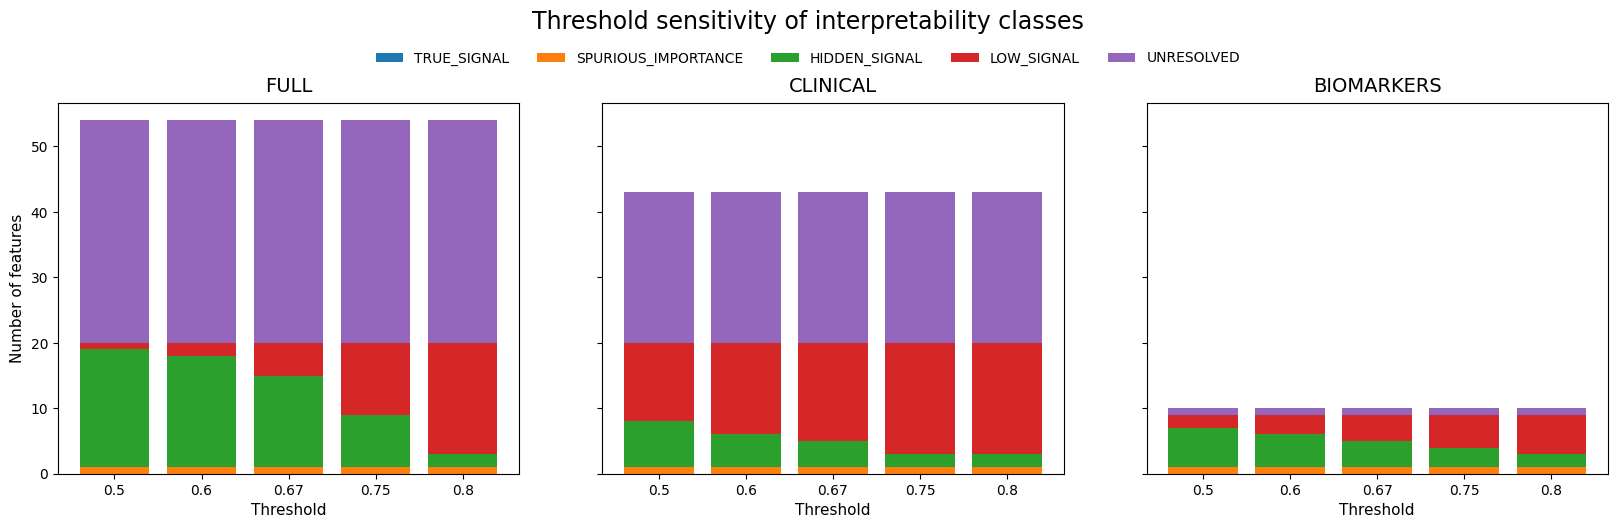

In [11]:

fig, axes = plt.subplots(1, 3, figsize=(20, 5.8), sharey=True)
fig.subplots_adjust(top=0.82, bottom=0.18, wspace=0.18)

for ax, variant in zip(axes, VARIANTS):
    sub = class_count_summary[class_count_summary["variant"] == variant].copy()
    pivot = sub.pivot(index="threshold", columns="feature_class_threshold", values="n_features").fillna(0)

    pivot = pivot.reindex(columns=CLASS_ORDER, fill_value=0)
    pivot.plot(kind="bar", stacked=True, ax=ax, width=0.8)

    ax.set_title(variant, fontsize=14, pad=8)
    ax.set_xlabel("Threshold", fontsize=11)
    ax.set_ylabel("Number of features", fontsize=11)
    ax.tick_params(axis="x", rotation=0, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

handles, labels = axes[-1].get_legend_handles_labels()
for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.legend(handles, labels, loc="upper center", ncol=5, frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.93))
fig.suptitle("Threshold sensitivity of interpretability classes", fontsize=17, y=0.98)
fig.savefig(OUT_DIR / "S17_plot_class_counts_across_thresholds.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

## Plot 2: agreement with base threshold

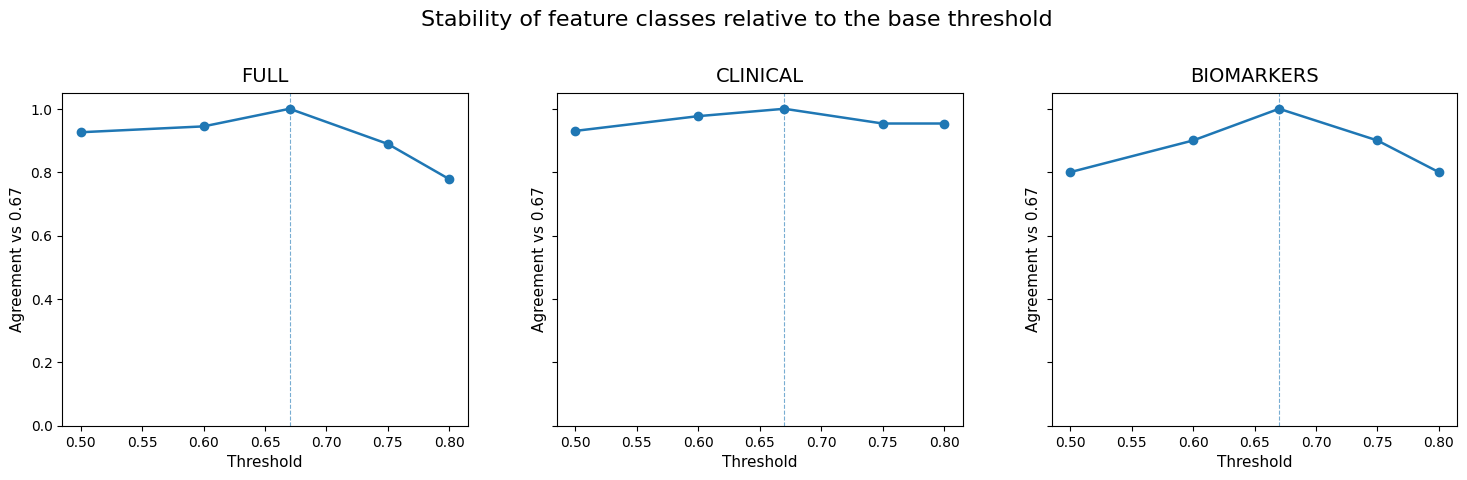

In [12]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), sharey=True)
fig.subplots_adjust(top=0.82, bottom=0.18, wspace=0.22)

for ax, variant in zip(axes, VARIANTS):
    sub = agreement_summary[agreement_summary["variant"] == variant].copy()
    ax.plot(sub["threshold"], sub["agreement_vs_base"], marker="o", linewidth=1.8)
    ax.axvline(BASE_THRESHOLD, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_title(variant, fontsize=14, pad=8)
    ax.set_xlabel("Threshold", fontsize=11)
    ax.set_ylabel("Agreement vs 0.67", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="both", labelsize=10)

fig.suptitle("Stability of feature classes relative to the base threshold", fontsize=16, y=0.98)
fig.savefig(OUT_DIR / "S17_plot_agreement_vs_base.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

## Plot 3: top-feature stability

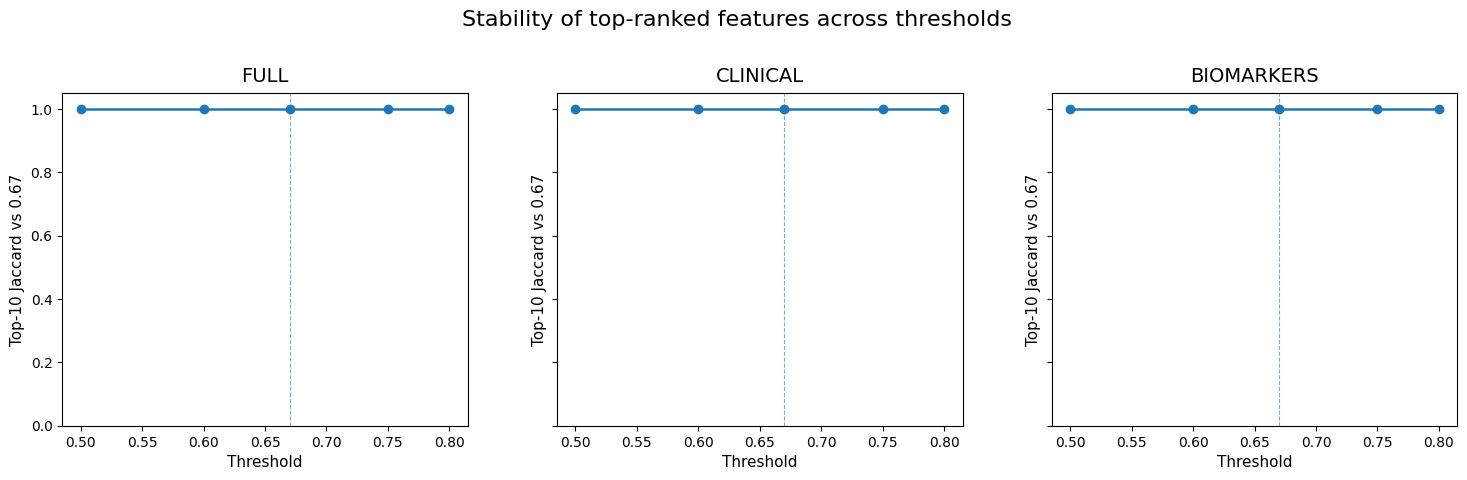

In [13]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), sharey=True)
fig.subplots_adjust(top=0.82, bottom=0.18, wspace=0.22)

for ax, variant in zip(axes, VARIANTS):
    sub = top_feature_stability[top_feature_stability["variant"] == variant].copy()
    ax.plot(sub["threshold"], sub["jaccard_vs_base"], marker="o", linewidth=1.8)
    ax.axvline(BASE_THRESHOLD, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_title(variant, fontsize=14, pad=8)
    ax.set_xlabel("Threshold", fontsize=11)
    ax.set_ylabel("Top-10 Jaccard vs 0.67", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="both", labelsize=10)

fig.suptitle("Stability of top-ranked features across thresholds", fontsize=16, y=0.98)
fig.savefig(OUT_DIR / "S17_plot_top_feature_stability.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

In [14]:
print("Saved outputs:")
for path in sorted(OUT_DIR.glob("S17_*")):
    print(path.name)

Saved outputs:
S17_agreement_vs_base.csv
S17_class_count_summary.csv
S17_class_count_summary_wide.csv
S17_config_snapshot.json
S17_plot_agreement_vs_base.png
S17_plot_class_counts_across_thresholds.png
S17_plot_top_feature_stability.png
S17_publication_summary.csv
S17_top_feature_stability.csv
S17_true_signal_summary.csv
